In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import os
import time
import copy

# Tekrarlanabilirlik için Seed ayarı 
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# GPU kontrolü
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")
if torch.cuda.is_available():
    print(f"GPU Modeli: {torch.cuda.get_device_name(0)}")




Kullanılan Cihaz: cuda
GPU Modeli: NVIDIA GeForce RTX 4060 Laptop GPU


In [11]:
data_dir = "panel_data" 

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

try:
    full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['train'])
    class_names = full_dataset.classes
    print(f"Sınıflar: {class_names}")

    # Split
    total_size = len(full_dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

    val_dataset.dataset.transform = data_transforms['val']
    test_dataset.dataset.transform = data_transforms['val']

    BATCH_SIZE = 96 
    
    dataloaders = {
        'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True),
        'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True),
        'test': DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    }
    dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}
    print(f"Batch Size: {BATCH_SIZE}")
    print(f"Veri Sayıları -> Train: {dataset_sizes['train']}, Val: {dataset_sizes['val']}, Test: {dataset_sizes['test']}")

except Exception as e:
    print("HATA:", e)

Sınıflar: ['Kirli', 'Temiz']
Batch Size: 96
Veri Sayıları -> Train: 2542, Val: 544, Test: 546


In [12]:
def train_model_with_scheduler(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    # Grafikler için kayıt tutucu
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and scheduler is not None:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(epoch_loss)
                    curr_lr = optimizer.param_groups[0]['lr']
                    # Sadece LR değiştiğinde ekrana yaz
                    # print(f"  -> Learning Rate: {curr_lr}") 

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Eğitim Tamamlandı: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'En İyi Val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

In [13]:
def visualize_history(history, title="Model"):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Accuracy Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')
    plt.grid(True)

    # Loss Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')
    plt.grid(True)
    plt.show()

def evaluate_model_full(model, title="Model"):
    model.eval()
    y_true = []
    y_pred = []
    y_probs = [] # ROC için olasılıklar
    
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            
            # Olasılık ve Tahmin
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs[:, 1].cpu().numpy()) # Pozitif sınıf (Dirty/1) olasılığı
            
    # 1. Classification Report
    print(f"\n--- {title} DETAYLI RAPOR ---")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} Confusion Matrix')
    plt.ylabel('Gerçek')
    plt.xlabel('Tahmin')
    plt.show()

    # 3. ROC Curve ve AUC
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title} ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

MODERN MİMARİ 1: ResNet-50 (Transfer Learning)
Epoch 1/12
----------
train Loss: 0.4280 Acc: 0.8045
val Loss: 0.9158 Acc: 0.8015

Epoch 2/12
----------
train Loss: 0.2643 Acc: 0.9001
val Loss: 1.0636 Acc: 0.7408

Epoch 3/12
----------
train Loss: 0.1683 Acc: 0.9382
val Loss: 0.6178 Acc: 0.8217

Epoch 4/12
----------
train Loss: 0.1379 Acc: 0.9441
val Loss: 0.5178 Acc: 0.8621

Epoch 5/12
----------
train Loss: 0.1096 Acc: 0.9579
val Loss: 0.7430 Acc: 0.8309

Epoch 6/12
----------
train Loss: 0.0977 Acc: 0.9646
val Loss: 0.6439 Acc: 0.8364

Epoch 7/12
----------
train Loss: 0.0972 Acc: 0.9721
val Loss: 0.5982 Acc: 0.8474

Epoch 8/12
----------
train Loss: 0.0606 Acc: 0.9795
val Loss: 0.4599 Acc: 0.8952

Epoch 9/12
----------
train Loss: 0.0518 Acc: 0.9819
val Loss: 0.4873 Acc: 0.8897

Epoch 10/12
----------
train Loss: 0.0459 Acc: 0.9858
val Loss: 0.5076 Acc: 0.8805

Epoch 11/12
----------
train Loss: 0.0288 Acc: 0.9906
val Loss: 0.5365 Acc: 0.9062

Epoch 12/12
----------
train Loss: 0.0

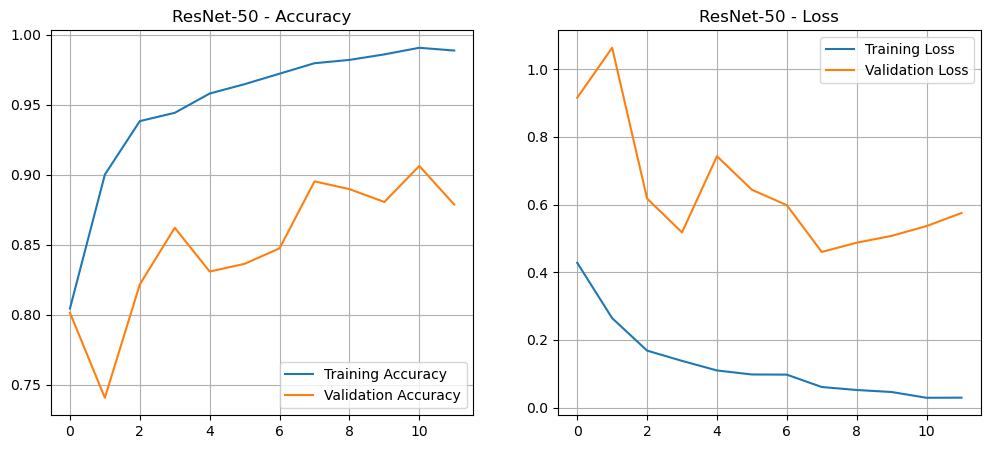


--- ResNet-50 DETAYLI RAPOR ---
              precision    recall  f1-score   support

       Kirli       0.89      0.92      0.90       255
       Temiz       0.93      0.90      0.91       291

    accuracy                           0.91       546
   macro avg       0.91      0.91      0.91       546
weighted avg       0.91      0.91      0.91       546



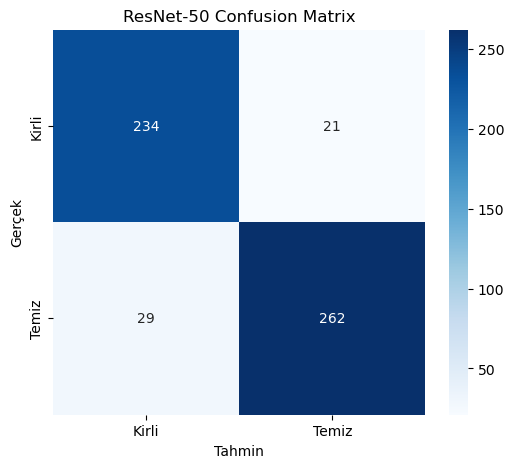

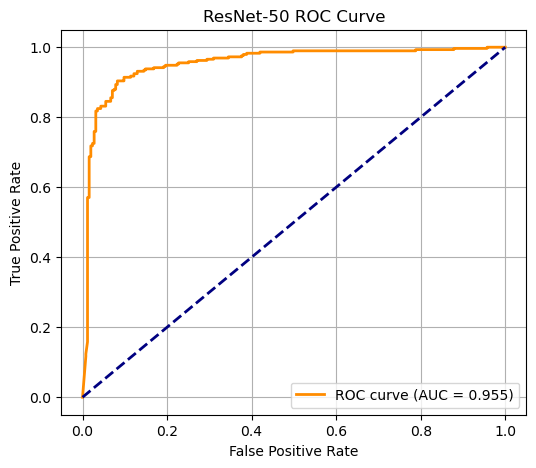

ResNet-50 Modeli Kaydedildi.


In [14]:
print("=========================================")
print("MODERN MİMARİ 1: ResNet-50 (Transfer Learning)")
print("=========================================")

# 1. Modeli Yükleme
model_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Son katmanı 2 sınıf (Clean/Dirty) için uyarma
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, 2)
model_resnet = model_resnet.to(device)

# 3. Loss ve Optimizer
criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)

# 4. Scheduler Ekleme 
exp_lr_scheduler = lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.1, patience=3, verbose=True)

# 5. Eğitim
model_resnet, history_resnet = train_model_with_scheduler(
    model_resnet, criterion, optimizer_resnet, exp_lr_scheduler, num_epochs=12
)

# 6. Değerlendir ve Kaydet
visualize_history(history_resnet, title="ResNet-50")
evaluate_model_full(model_resnet, title="ResNet-50")
torch.save(model_resnet.state_dict(), 'PATtechs_ResNet50_Final.pth')
print("ResNet-50 Modeli Kaydedildi.")

MODERN MİMARİ 2: DenseNet-121 (Comparison)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Rabotyaga/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth
100.0%
c:\ProgramData\anaconda3\envs\My_new_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/12
----------
train Loss: 0.4594 Acc: 0.7848
val Loss: 0.5945 Acc: 0.7371

Epoch 2/12
----------
train Loss: 0.2985 Acc: 0.8859
val Loss: 0.3827 Acc: 0.8456

Epoch 3/12
----------
train Loss: 0.2092 Acc: 0.9190
val Loss: 0.6229 Acc: 0.7996

Epoch 4/12
----------
train Loss: 0.1719 Acc: 0.9359
val Loss: 0.5340 Acc: 0.8327

Epoch 5/12
----------
train Loss: 0.1458 Acc: 0.9473
val Loss: 0.4878 Acc: 0.8621

Epoch 6/12
----------
train Loss: 0.1446 Acc: 0.9457
val Loss: 0.7063 Acc: 0.8235

Epoch 7/12
----------
train Loss: 0.0876 Acc: 0.9685
val Loss: 0.3702 Acc: 0.9007

Epoch 8/12
----------
train Loss: 0.0410 Acc: 0.9898
val Loss: 0.3753 Acc: 0.9007

Epoch 9/12
----------
train Loss: 0.0285 Acc: 0.9933
val Loss: 0.3842 Acc: 0.9099

Epoch 10/12
----------
train Loss: 0.0222 Acc: 0.9949
val Loss: 0.4066 Acc: 0.9007

Epoch 11/12
----------
train Loss: 0.0176 Acc: 0.9957
val Loss: 0.4218 Acc: 0.9007

Epoch 12/12
----------
train Loss: 0.0139 Acc: 0.9949
val Loss: 0.4145 Acc: 0.9081

E

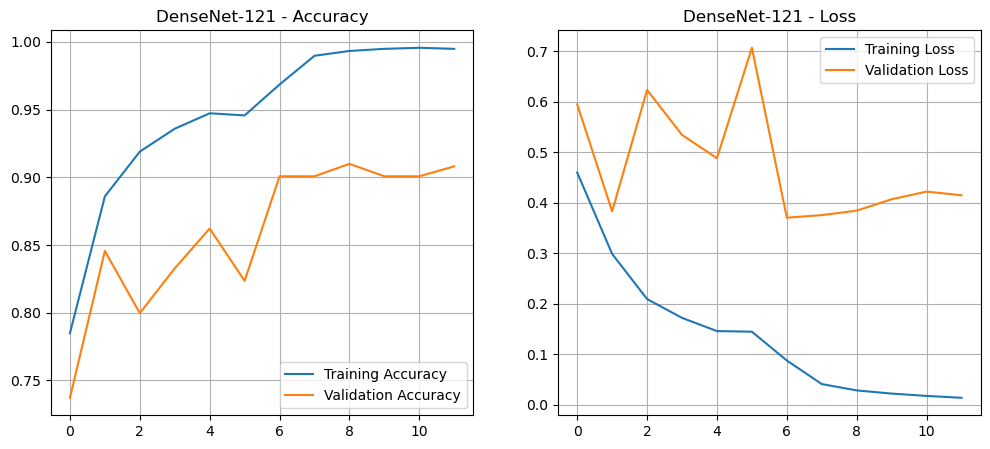


--- DenseNet-121 DETAYLI RAPOR ---
              precision    recall  f1-score   support

       Kirli       0.86      0.90      0.88       255
       Temiz       0.91      0.87      0.89       291

    accuracy                           0.89       546
   macro avg       0.89      0.89      0.89       546
weighted avg       0.89      0.89      0.89       546



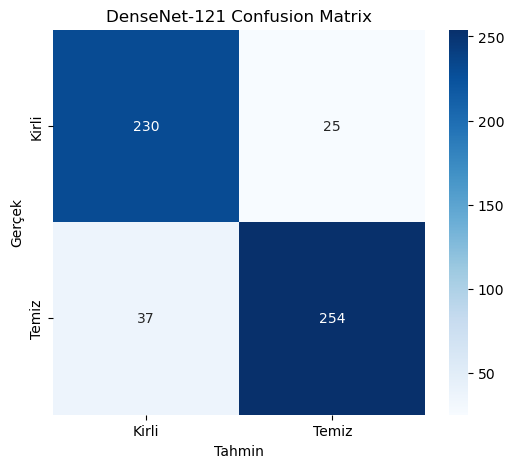

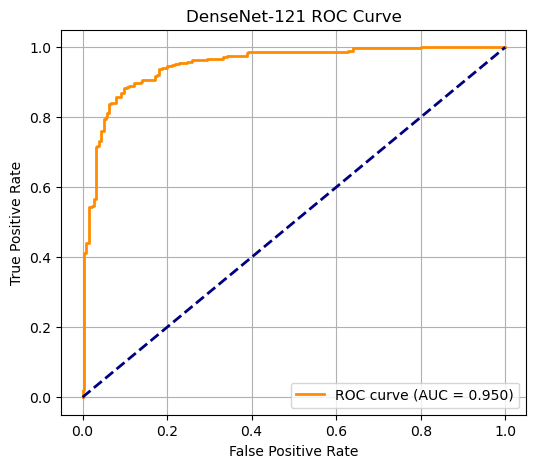

DenseNet-121 Modeli Kaydedildi.


In [15]:
print("=========================================")
print("MODERN MİMARİ 2: DenseNet-121 (Comparison)")
print("=========================================")

# 1. Modeli Yükleme
model_dense = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# 2. Son katmanı uyarlama
num_ftrs = model_dense.classifier.in_features
model_dense.classifier = nn.Linear(num_ftrs, 2)
model_dense = model_dense.to(device)

# 3. Loss ve Optimizer
criterion = nn.CrossEntropyLoss()
optimizer_dense = optim.Adam(model_dense.parameters(), lr=0.001)

# 4. Scheduler Ekleme
exp_lr_scheduler_dense = lr_scheduler.ReduceLROnPlateau(optimizer_dense, mode='min', factor=0.1, patience=3, verbose=True)

# 5. Eğitim
model_dense, history_dense = train_model_with_scheduler(
    model_dense, criterion, optimizer_dense, exp_lr_scheduler_dense, num_epochs=12
)

# 6. Değerlendirme ve Kaydetme
visualize_history(history_dense, title="DenseNet-121")
evaluate_model_full(model_dense, title="DenseNet-121")
torch.save(model_dense.state_dict(), 'PATtechs_DenseNet121_Final.pth')
print("DenseNet-121 Modeli Kaydedildi.")


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
     -- ------------------------------------- 0.5/7.8 MB 1.3 MB/s eta 0:00:06
     ---- ----------------------------------- 0.8/7.8 MB 1.4 MB/s eta 0:00:06
     ----- ---------------------------------- 1.0/7.8 MB 1.4 MB/s eta 0:00:05
     ------ --------------------------------- 1.3/7.8 MB 1.4 MB/s eta 0:00:05
     -------- ------------------------------- 1.6/7.8 MB 1.4 MB/s eta 0:00:05
     --------- ------------------------------ 1.8/7.8 MB 1.3 MB/s eta 0:00:05
     ---------- ----------------------------- 2.1/7.8 MB 1.3 MB/s eta 0:00:05
     ------------ --------------------------- 2.4/7.8 MB 1.4 MB/s eta 0:00:05
     ------------- -------------------------- 2.6/7.8 MB 1.3 MB/s eta 0:00:04
     -------------- ------------------------- 2.9/7.8 MB 1.4 MB/s eta 0:00:04
     ---------------- ----------------------- 3.1/7.8 MB 1.4 MB/s eta 0:00:04


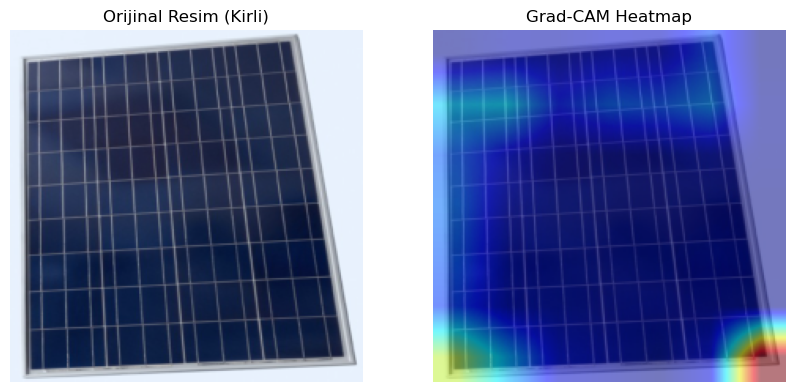

In [16]:
# Grad-CAM kodları 
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import sys
    !{sys.executable} -m pip install grad-cam
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def visualize_gradcam(model, target_layer, dataset, device):
    model.eval()
    found = False
    while not found:
        idx = np.random.randint(0, len(dataset))
        img, label = dataset[idx]
        if label == 1: 
            found = True

    input_tensor = img.unsqueeze(0).to(device)
    rgb_img = img.permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(1)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title("Orijinal Resim (Kirli)")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')
    plt.show()

print("Heatmap Çiziliyor...")
# ResNet50 için layer4[-1], DenseNet için features.denseblock4.denselayer16 gibi değişir. 
# ResNet garantidir:
visualize_gradcam(model_resnet, model_resnet.layer4[-1], test_dataset, device)

In [17]:
def measure_speed(model, device, model_name="Model"):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        for _ in range(10): _ = model(dummy_input)
            
    start = time.time()
    with torch.no_grad():
        for _ in range(100): _ = model(dummy_input)
    end = time.time()
    
    avg_time = (end - start) / 100
    print(f"{model_name} Ortalama Tahmin Süresi: {avg_time*1000:.2f} ms")

measure_speed(model_resnet, device, "ResNet-50")
measure_speed(model_dense, device, "DenseNet-121")

ResNet-50 Ortalama Tahmin Süresi: 38.54 ms
DenseNet-121 Ortalama Tahmin Süresi: 41.73 ms
